# ERA5 India 2025 — Descriptive Analysis
Wind (`wcf`) and solar (`scf`) capacity factors computed from hourly ERA5 reanalysis.

In [2]:
import xarray as xr

path = 'C:\\Users\\colin\\Documents\\These\\Recherche\\Renewable_india\\data\\raw\\era5_test\\era5_india_2020_6h_ssrd_test.grib'
ds = xr.open_dataset(path, engine='cfgrib')

# time is 732 (366*2) and I have a step 2
#flatten time and step to get 1464 timestamps
ds = ds.stack(time_step=('time', 'step')).reset_index('time_step')
ds['ssrd'] = ds['ssrd'] / (3600*6)  # convert from J m-2 to W m-2
# ds.isel(time_step=349).ssrd.plot()
#resample to daily mean


In [12]:
import xarray as xr
path = "../../../data/raw/era5_daily/era5_tasmax_1980_2020.nc"
dtasmax = xr.open_dataset(path)
path_tas = "../../../data/raw/era5_daily/era5_tas_1980_2020.nc"
dtas = xr.open_dataset(path_tas)

In [ ]:
dtasmax = dtasmax.isel(lat=0, lon=0).convert_calendar("noleap").sel(time=slice('1980-01-01', '2010-12-31'))
dtasmax = dtasmax.dropna('time', how='all')
#are there duplicates timestamps?
dtasmax.get_index('time').duplicated().any()
#keep only the duplicates
dup_mask = dtasmax.get_index('time').duplicated()
dtasmax_clean = dtasmax.isel(time=~dup_mask)  # keep first occurrence, drop duplicate timestamps


In [15]:
dup_mask

array([False, False, False, ..., False, False,  True])

In [7]:
11315/365

31.0

In [3]:
dtas = dtas.isel(lat=0, lon=0).convert_calendar("noleap").sel(time=slice('1980-01-01', '2010-12-31'))


In [4]:
dtas = dtas.dropna(dim='time', how='all')
dtas

<xarray.Dataset> Size: 136kB
Dimensions:  (time: 11315)
Coordinates:
    lat      float64 8B 37.0
    lon      float64 8B 68.0
  * time     (time) object 91kB 1980-01-01 00:00:00 ... 2010-12-31 00:00:00
    number   int32 4B 0
    step     timedelta64[ns] 8B 00:00:00
    surface  float64 8B 0.0
Data variables:
    tas      (time) float32 45kB 279.8 279.1 278.1 278.5 ... 275.0 275.9 275.3

In [4]:
path = 'C:\\Users\\colin\\Documents\\These\\Recherche\\Renewable_india\\data\\raw\\era5_daily\\era5_rsds_1980_2020.nc'
ds = xr.open_dataset(path)
ds.rsds.isel(time=slice(None,40)).mean(dim='time').plot()

<xarray.DataArray 'rsds' ()> Size: 8B
array(416.00445557)
Coordinates:
    number   int32 4B ...
    step     timedelta64[ns] 8B ...
    surface  float64 8B ...

In [8]:
path = "E:\temp\GFDL-ESM4\diurnal_library_GFDL-ESM4.nc"
ds = xr.open_dataset(path, engine='cfgrib')

Can't create file 'E:\temp\\GFDL-ESM4\\diurnal_library_GFDL-ESM4.nc.5b7b6.idx'
Traceback (most recent call last):
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\site-packages\cfgrib\messages.py", line 538, in from_indexpath_or_filestream
    with compat_create_exclusive(indexpath) as new_index_file:
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\contextlib.py", line 135, in __enter__
    return next(self.gen)
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\site-packages\cfgrib\messages.py", line 504, in compat_create_exclusive
    fd = os.open(path, os.O_WRONLY | os.O_CREAT | os.O_EXCL)
OSError: [Errno 22] Invalid argument: 'E:\temp\\GFDL-ESM4\\diurnal_library_GFDL-ESM4.nc.5b7b6.idx'
Can't read index file 'E:\temp\\GFDL-ESM4\\diurnal_library_GFDL-ESM4.nc.5b7b6.idx'
Traceback (most recent call last):
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\site-packages\cfgrib\messages.py", line 548, in from_indexpath_or_filestream
    index_mtime = os.path.getmtime(indexpath)
  File "c:\U

OSError: [Errno 22] Invalid argument: 'E:\temp\\GFDL-ESM4\\diurnal_library_GFDL-ESM4.nc'

In [2]:
import xarray as xr
path_h = '../../../data/raw/era5/era5_india_2019_hourly.grib'
ds_h = xr.open_dataset(path_h, engine='cfgrib')
ds_h

skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "c:\Users\colin\anaconda3\envs\xr_env\lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1546300800, 1546304400, 1546308000, ..., 1577826000, 1577829600,
       1577833200])) new_value=Variable(dimensions=('time',), data=array([1546279200, 1546322400, 1546365600, 1546408800, 1546452000,
       1546495200, 1546538400, 1546581600, 1546624800, 1546668000,
       1546711200, 1546754400, 1546797600, 1546840800, 1546884000,
       1546927200, 1546970400, 1547013600, 1547056800, 1547100000,
       1547143200, 1547186400, 1547229600, 1547272800, 1547316000,
       1547359200, 1

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 8760, latitude: 125, longitude: 117)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-31T23:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 37.0 36.75 36.5 36.25 ... 6.5 6.25 6.0
  * longitude   (longitude) float64 936B 68.0 68.25 68.5 ... 96.5 96.75 97.0
    valid_time  (time) datetime64[ns] 70kB ...
Data variables:
    t2m         (time, latitude, longitude) float32 512MB ...
    u10         (time, latitude, longitude) float32 512MB ...
    v10         (time, latitude, longitude) float32 512MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-04T11:11 GRIB to CDM+CF via cfgrib-0.9.1...

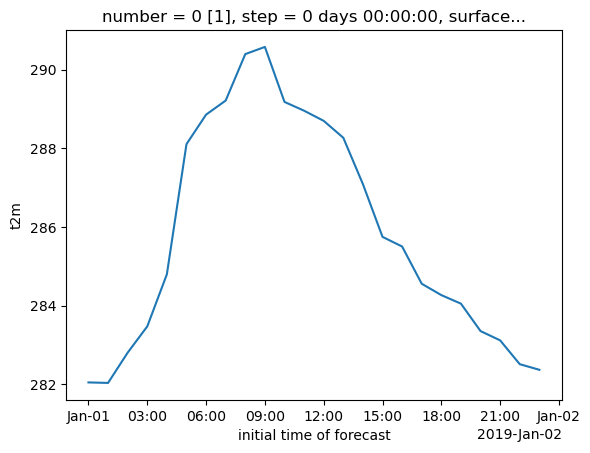

In [9]:
ds_h.isel(time=slice(None,24)).t2m.mean(dim=['latitude', 'longitude']).plot()

In [ ]:
ds = xr.open_dataset(
        str(path_h), engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "ssrd"}},
    )
ds = ds.fillna(0)


Ignoring index file '../../../data/raw/era5/era5_india_2019_hourly.grib.47d85.idx' incompatible with GRIB file


In [ ]:
def load_ssrd_hourly(grib_path):
    """
    Load ssrd from hourly GRIB.
    ERA5 hourly ssrd is cumulative from each forecast init (06/18 UTC).
    Deaccumulate with np.diff along the step axis, flatten to (time, lat, lon).
    """
    ds = xr.open_dataset(
        str(grib_path), engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "ssrd"}},
    )
    ds = xr.open_dataset(
        str(grib_path), engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "ssrd"}},
    )
    ds = ds.fillna(0)
    ds['time_step'] = ds['time'] + ds['step']
    ds = ds.stack(time_dim=('time', 'step')).reset_index('time_dim')
    ds['time_dim'] = ds['time'] + ds['step']
    ds['ssrd'] = ds['ssrd'] / (3600)  # convert from J m-2 to W m-2
    #drop time and step
    ds = ds.drop(['time', 'step'])
    ds = ds.rename({'time_dim': 'time', 'latitude': 'lat', 'longitude': 'lon'})
    ds = ds.drop_vars(['surface', 'number', 'valid_time', 'time_step'])
    ds = ds.rename({'ssrd': 'rsds'})
    ds = ds.sel(time = slice(str(YEAR) + '-01-01', str(YEAR) + '-12-31'))

    return ds


In [ ]:
grib_path = '../../../data/raw/era5/era5_india_2019_hourly.grib'
ds = xr.open_dataset(
        str(grib_path), engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "ssrd"}},
    )
ds = ds.fillna(0)


ds['time_step'] = ds['time'] + ds['step']
ds = ds.stack(time_dim=('time', 'step')).reset_index('time_dim')
ds['time_dim'] = ds['time'] + ds['step']
ds['ssrd'] = ds['ssrd'] / (3600)  # convert from J m-2 to W m-2
#drop time and step
ds = ds.drop(['time', 'step'])
ds = ds.rename({'time_dim': 'time', 'latitude': 'lat', 'longitude': 'lon'})
ds = ds.drop_vars(['surface', 'number', 'valid_time', 'time_step'])
ds = ds.rename({'ssrd': 'rsds'})


Ignoring index file '../../../data/raw/era5/era5_india_2019_hourly.grib.47d85.idx' incompatible with GRIB file
C:\Users\colin\AppData\Local\Temp\ipykernel_15204\117536904.py:13: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds = ds.drop(['time', 'step'])


In [ ]:

ds

<xarray.Dataset> Size: 513MB
Dimensions:  (lat: 125, lon: 117, time: 8772)
Coordinates:
  * lat      (lat) float64 1kB 37.0 36.75 36.5 36.25 36.0 ... 6.75 6.5 6.25 6.0
  * lon      (lon) float64 936B 68.0 68.25 68.5 68.75 ... 96.25 96.5 96.75 97.0
  * time     (time) datetime64[ns] 70kB 2018-12-31T19:00:00 ... 2020-01-01T06...
Data variables:
    rsds     (lat, lon, time) float32 513MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-04T11:30 GRIB to CDM+CF via cfgrib-0.9.1...

In [28]:
dsplot = ds.isel(time=slice(None,5)).ssrd.mean(dim=['latitude', 'longitude'])
dsplot['time_step'] = dsplot['time'] + dsplot['step']
dsplot = dsplot.stack(time_dim=('time', 'step')).reset_index('time_dim')
dsplot['time_dim'] = dsplot['time'] + dsplot['step']
dsplot = dsplot / (3600)  # convert from J m-2 to W m-2
dsplot.time_step
#put time_step as the dimension
dsplot.time_dim

<xarray.DataArray 'time_dim' (time_dim: 60)> Size: 480B
array(['2018-12-31T19:00:00.000000000', '2018-12-31T20:00:00.000000000',
       '2018-12-31T21:00:00.000000000', '2018-12-31T22:00:00.000000000',
       '2018-12-31T23:00:00.000000000', '2019-01-01T00:00:00.000000000',
       '2019-01-01T01:00:00.000000000', '2019-01-01T02:00:00.000000000',
       '2019-01-01T03:00:00.000000000', '2019-01-01T04:00:00.000000000',
       '2019-01-01T05:00:00.000000000', '2019-01-01T06:00:00.000000000',
       '2019-01-01T07:00:00.000000000', '2019-01-01T08:00:00.000000000',
       '2019-01-01T09:00:00.000000000', '2019-01-01T10:00:00.000000000',
       '2019-01-01T11:00:00.000000000', '2019-01-01T12:00:00.000000000',
       '2019-01-01T13:00:00.000000000', '2019-01-01T14:00:00.000000000',
       '2019-01-01T15:00:00.000000000', '2019-01-01T16:00:00.000000000',
       '2019-01-01T17:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-01T19:00:00.000000000', '2019-01-01T20:00:00.000000000',
       '2019-01-01T21:00:00.000000000', '2019-01-01T22:00:00.000000000',
       '2019-01-01T23:00:00.000000000', '2019-01-02T00:00:00.000000000',
       '2019-01-02T01:00:00.000000000', '2019-01-02T02:00:00.000000000',
       '2019-01-02T03:00:00.000000000', '2019-01-02T04:00:00.000000000',
       '2019-01-02T05:00:00.000000000', '2019-01-02T06:00:00.000000000',
       '2019-01-02T07:00:00.000000000', '2019-01-02T08:00:00.000000000',
       '2019-01-02T09:00:00.000000000', '2019-01-02T10:00:00.000000000',
       '2019-01-02T11:00:00.000000000', '2019-01-02T12:00:00.000000000',
       '2019-01-02T13:00:00.000000000', '2019-01-02T14:00:00.000000000',
       '2019-01-02T15:00:00.000000000', '2019-01-02T16:00:00.000000000',
       '2019-01-02T17:00:00.000000000', '2019-01-02T18:00:00.000000000',
       '2019-01-02T19:00:00.000000000', '2019-01-02T20:00:00.000000000',
       '2019-01-02T21:00:00.000000000', '2019-01-02T22:00:00.000000000',
       '2019-01-02T23:00:00.000000000', '2019-01-03T00:00:00.000000000',
       '2019-01-03T01:00:00.000000000', '2019-01-03T02:00:00.000000000',
       '2019-01-03T03:00:00.000000000', '2019-01-03T04:00:00.000000000',
       '2019-01-03T05:00:00.000000000', '2019-01-03T06:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    number      int32 4B 0
    surface     float64 8B 0.0
    valid_time  (time_dim) datetime64[ns] 480B 2018-12-31T19:00:00 ... 2019-0...
    time_step   (time_dim) datetime64[ns] 480B 2018-12-31T19:00:00 ... 2019-0...
    time        (time_dim) datetime64[ns] 480B 2018-12-31T18:00:00 ... 2019-0...
    step        (time_dim) timedelta64[ns] 480B 01:00:00 02:00:00 ... 12:00:00
  * time_dim    (time_dim) datetime64[ns] 480B 2018-12-31T19:00:00 ... 2019-0...

In [30]:
dsplot.resample(time_dim='1D').mean()

<xarray.DataArray 'ssrd' (time_dim: 4)> Size: 16B
array([  0.     , 189.47322, 188.99329, 273.35083], dtype=float32)
Coordinates:
    number    int32 4B 0
    surface   float64 8B 0.0
  * time_dim  (time_dim) datetime64[ns] 32B 2018-12-31 2019-01-01 ... 2019-01-03

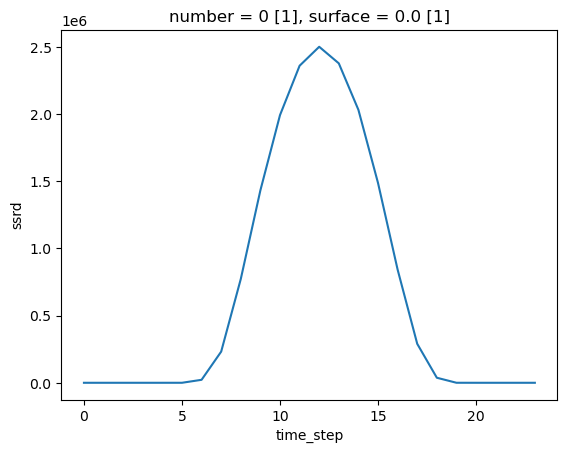

In [14]:
dsplot = ds.isel(time=slice(None,2)).ssrd.mean(dim=['latitude', 'longitude'])
#flatten
dsplot = dsplot.stack(time_step=('time', 'step')).reset_index('time_step')
dsplot.plot()

In [5]:
ds

<xarray.Dataset> Size: 513MB
Dimensions:     (time: 731, step: 12, latitude: 125, longitude: 117)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 6kB 2018-12-31T18:00:00 ... 2019-12-31T...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 37.0 36.75 36.5 36.25 ... 6.5 6.25 6.0
  * longitude   (longitude) float64 936B 68.0 68.25 68.5 ... 96.5 96.75 97.0
    valid_time  (time, step) datetime64[ns] 70kB ...
Data variables:
    ssrd        (time, step, latitude, longitude) float32 513MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-04T11:13 GRIB to CDM+CF via cfgrib-0.9.1...

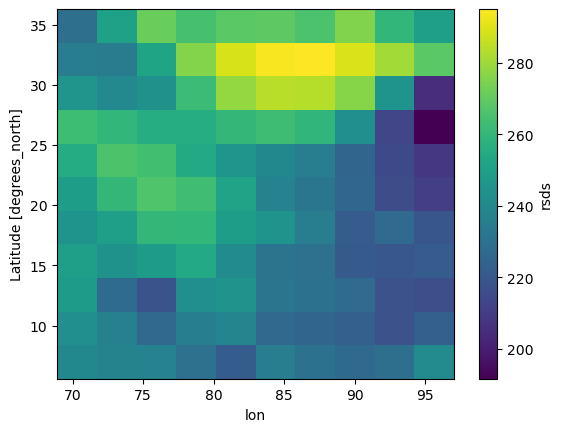

In [67]:
path_Can = '../../../data\\raw\\CanESM5\\rsds_day_CanESM5_historical_r10i1p1f1_185001-201412_india.nc'
ds_Can = xr.open_dataset(path_Can)
ds_Can.rsds.mean(dim='time').plot()

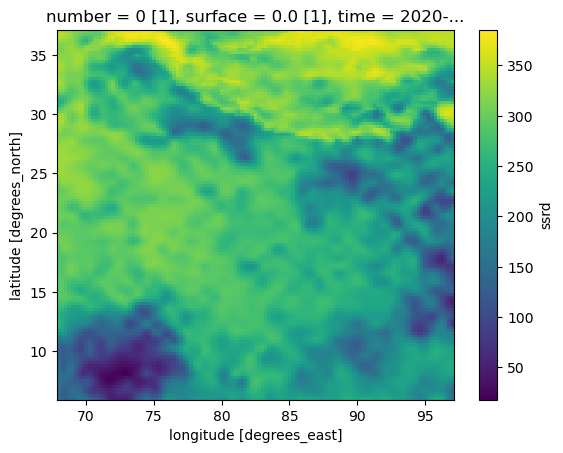

In [69]:
path = 'C:\\Users\\colin\\Documents\\These\\Recherche\\Renewable_india\\data\\raw\\era5_test\\era5_india_2020_6h_ssrd_test.grib'
ds = xr.open_dataset(path, engine='cfgrib')
ds_daily = ds.resample(time='1D').sum().sum(dim='step')
ds_daily['ssrd'] = ds_daily['ssrd'] / (3600*4)  # convert from J m-2 to W m-2
ds_daily.isel(time=150).ssrd.plot()

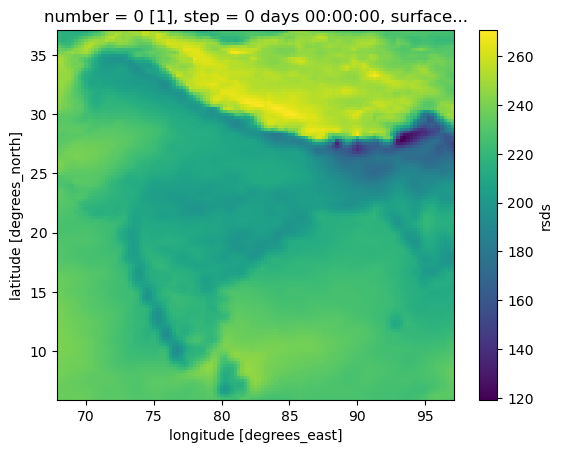

In [43]:
path2019 = '../../../data/raw/era5/era5_india_2019_hourly.nc'
ds_2019 = xr.open_dataset(path2019)
ds_2019.resample(time='1D').mean().mean(dim='time').rsds.plot()

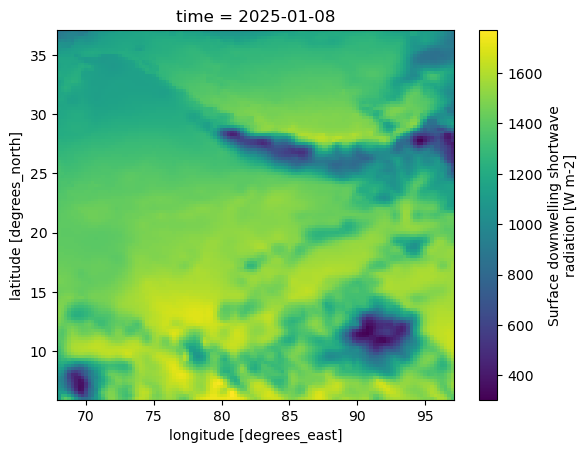

In [70]:
path = '../../../data/raw/era5/era5_india_2025_hourly.nc'
dsh = xr.open_dataset(path)
dsh = dsh.fillna(0)
dsh = dsh.resample(time='1D').sum()
(dsh.isel(time=7).rsds).plot()

(array([8.1813400e+05, 3.8865897e+07, 1.0979744e+08, 5.1194963e+07,
        9.8827740e+06, 2.4468620e+06, 6.6552600e+05, 1.7785100e+05,
        3.6714000e+04, 4.4640000e+03]),
 array([0.92673165, 1.230426  , 1.53412036, 1.83781471, 2.14150906,
        2.44520341, 2.74889777, 3.05259212, 3.35628647, 3.65998082,
        3.96367517]),
 <BarContainer object of 10 artists>)

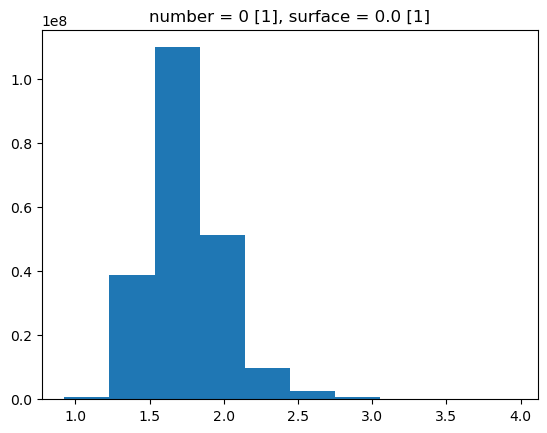

In [63]:
(dsh.mean(dim='time').rsds/ds_daily.mean(dim='time').ssrd).plot()

tas


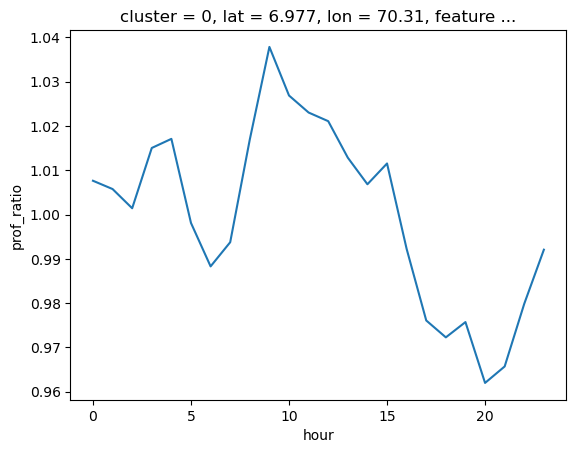

In [58]:
path_diu = "C:\\Users\\colin\\Downloads\\diurnal_library_CanESM5.nc"
ds_diu = xr.open_dataset(path_diu)
print(ds_diu.isel(cluster=0, feature=1, lat=0, lon=0).feature.values)
# ds_diu.isel(cluster=0, feature=0, lat=0, lon=0).prof_anom.plot()
# ds_diu.isel(cluster=0, feature=1, lat=0, lon=0).prof_frac.plot()
ds_diu.isel(cluster=0, feature=0, lat=0, lon=0).prof_ratio.plot()

In [15]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

wcf = xr.open_dataset('../../../data/proc/era5/wcf_era5_india_2025_hourly.nc')['wcf']
scf = xr.open_dataset('../../../data/proc/era5/scf_era5_india_2025_hourly.nc')['scf'].clip(min=0)

print('wcf:', wcf.dims, wcf.shape)
print('scf:', scf.dims, scf.shape)

wcf: ('time', 'lat', 'lon') (8760, 125, 117)
scf: ('time', 'lat', 'lon') (8760, 125, 117)


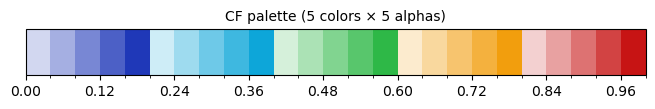

In [16]:
import matplotlib.colors as mcolors

# Custom colormap: 5 hues × 5 alpha levels = 25 discrete steps
# Hues match the reference palette: blue → cyan → green → orange → red
_base_colors = [
    (0.12, 0.22, 0.72),   # blue
    (0.05, 0.65, 0.85),   # cyan
    (0.18, 0.72, 0.28),   # green
    (0.95, 0.62, 0.05),   # orange
    (0.78, 0.08, 0.08),   # red
]
_alphas = [0.2, 0.4, 0.6, 0.8, 1.0]

_rgba = [(*rgb, a) for rgb in _base_colors for a in _alphas]
CF_CMAP = mcolors.ListedColormap(_rgba, name='cf_palette')
CF_CMAP.set_bad(color='lightgrey')   # NaN -> grey

# Colorbar boundaries for 25 bins
def cf_norm(vmin, vmax):
    return mcolors.BoundaryNorm(np.linspace(vmin, vmax, 26), CF_CMAP.N)

# Quick preview
fig, ax = plt.subplots(figsize=(8, 0.6))
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=CF_CMAP, norm=cf_norm(0, 1)),
                  cax=ax, orientation='horizontal')
ax.set_title('CF palette (5 colors × 5 alphas)', fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
scf

<xarray.DataArray 'scf' (time: 8760, lat: 125, lon: 117)> Size: 512MB
array([[[0.        , 0.        , 0.        , ..., 0.00175799,
         0.00218539, 0.00264663],
        [0.        , 0.        , 0.        , ..., 0.00166003,
         0.00205303, 0.0024644 ],
        [0.        , 0.        , 0.        , ..., 0.00155689,
         0.0018978 , 0.0022589 ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.08183017,
         0.08888765, 0.09538671],
        [0.        , 0.        , 0.        , ..., 0.08444922,
         0.09097079, 0.09724754],
        [0.        , 0.        , 0.        , ..., 0.08807005,
         0.09344951, 0.09895498],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23:00:00
  * lat      (lat) float64 1kB 6.0 6.25 6.5 6.75 7.0 ... 36.25 36.5 36.75 37.0
  * lon      (lon) float64 936B 68.0 68.25 68.5 68.75 ... 96.25 96.5 96.75 97.0

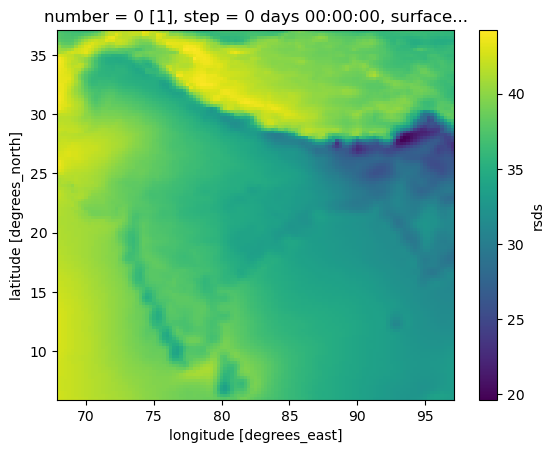

In [12]:
import xarray as xr
path = '../../../data/raw/era5_daily/era5_rsds_1980_2020.nc'
ds = xr.open_dataset(path)
ds.mean(dim='time').rsds.plot()

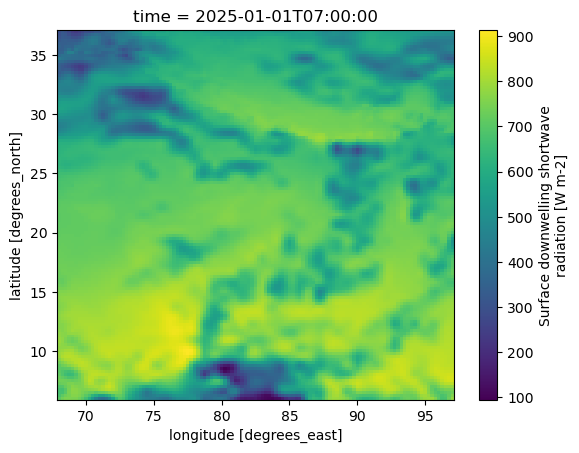

## 1. Annual mean capacity factors

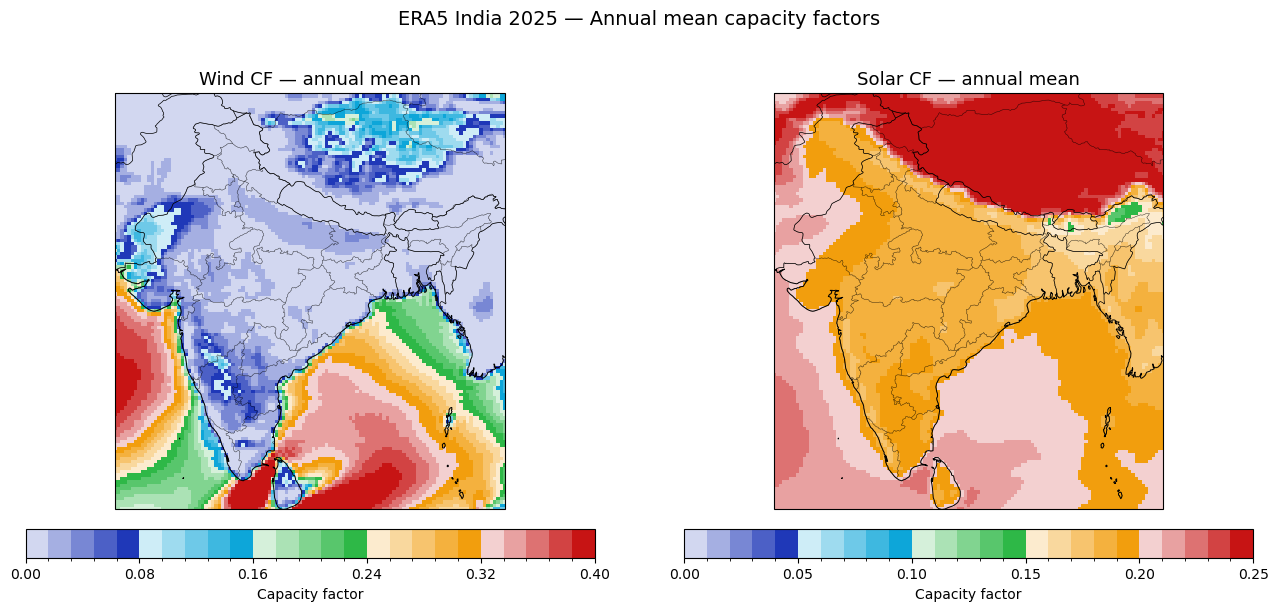

In [18]:
wcf_mean = wcf.mean('time').compute()
scf_mean = scf.mean('time', skipna=True).compute()

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, da, title, vmin, vmax in [
    (axes[0], wcf_mean, 'Wind CF — annual mean',  0.0, 0.40),
    (axes[1], scf_mean, 'Solar CF — annual mean', 0.0, 0.25),
]:
    norm = cf_norm(vmin, vmax)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    im = ax.pcolormesh(da.lon, da.lat, da.values,
                       cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.8,
                 label='Capacity factor', ticks=np.linspace(vmin, vmax, 6))
    ax.set_title(title, fontsize=13)
    ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())

plt.suptitle('ERA5 India 2025 — Annual mean capacity factors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_annual_mean_cf.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Seasonal means

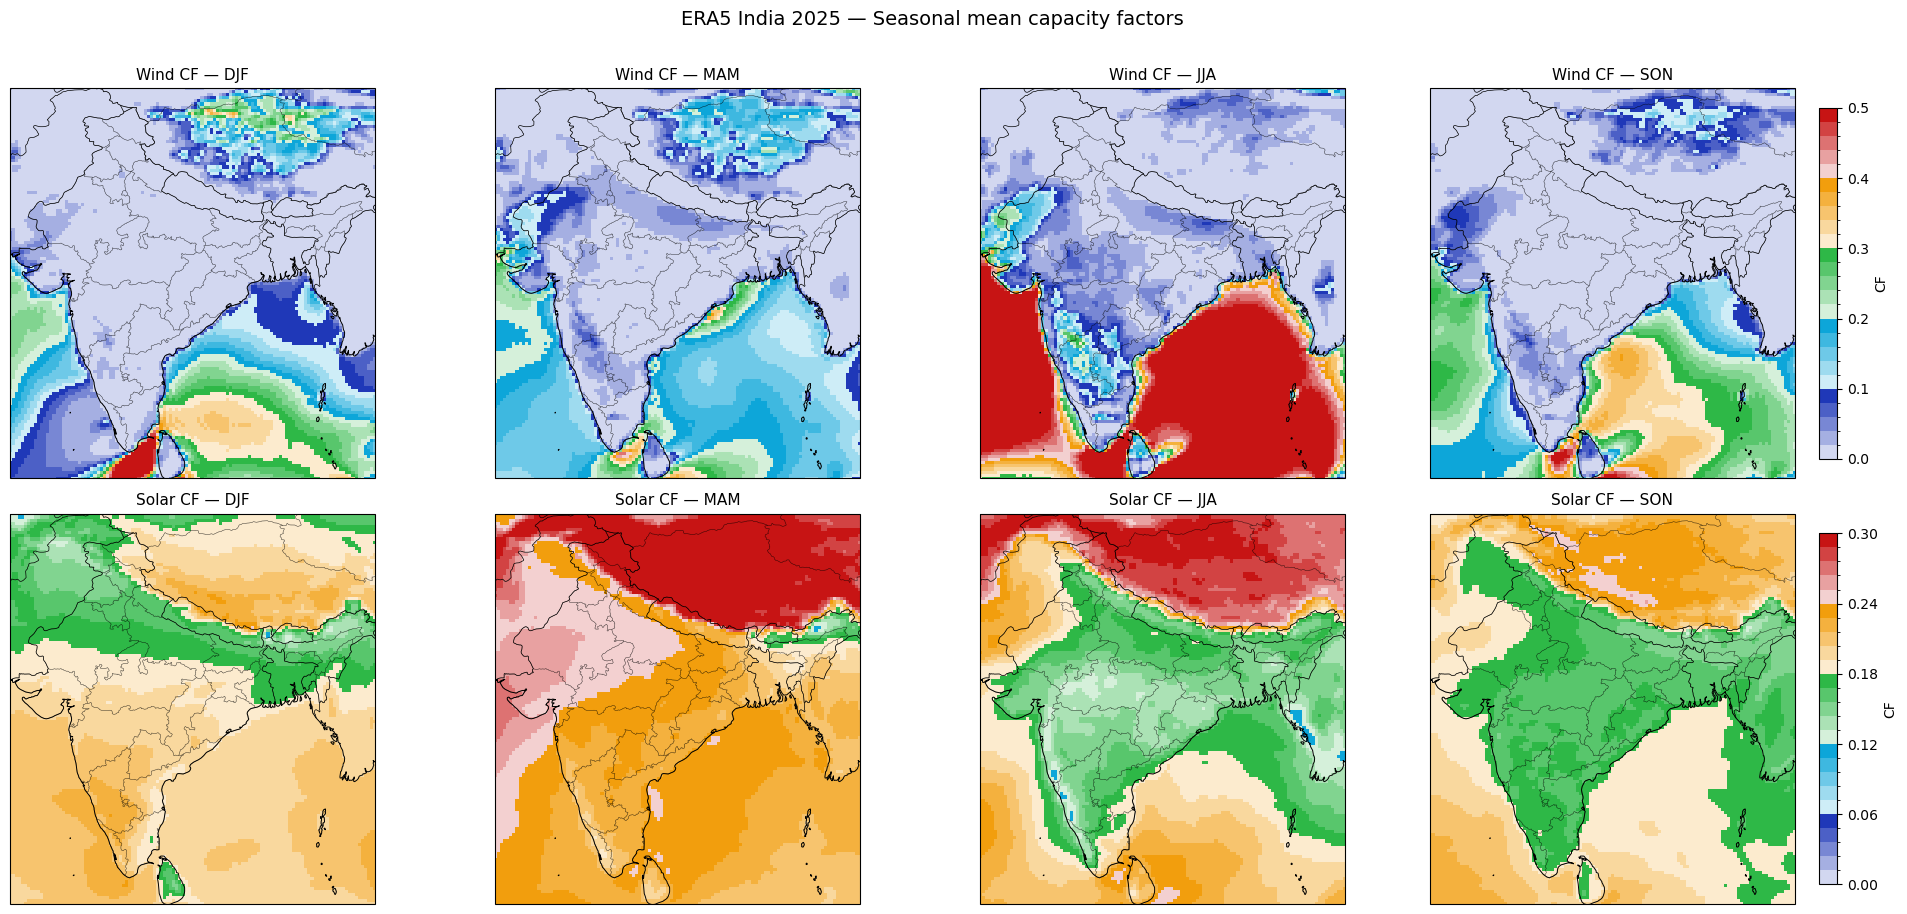

In [19]:
season_months = {'DJF': [12,1,2], 'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9,10,11]}

vmaxes = {'Wind CF': 0.50, 'Solar CF': 0.30}

fig, axes = plt.subplots(2, 4, figsize=(20, 9),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for row, (da, label, vmax) in enumerate([
    (wcf, 'Wind CF',  0.50),
    (scf, 'Solar CF', 0.30),
]):
    norm = cf_norm(0, vmax)
    for col, (season, months) in enumerate(season_months.items()):
        da_s = da.sel(time=da.time.dt.month.isin(months)).mean('time').compute()
        ax = axes[row, col]
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
        im = ax.pcolormesh(da_s.lon, da_s.lat, da_s.values,
                           cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
        ax.set_title(f'{label} — {season}', fontsize=11)
        ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())
        if col == 3:
            plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.9,
                         label='CF', ticks=np.linspace(0, vmax, 6))

plt.suptitle('ERA5 India 2025 — Seasonal mean capacity factors', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_seasonal_cf.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly mean time series (India-wide spatial average)

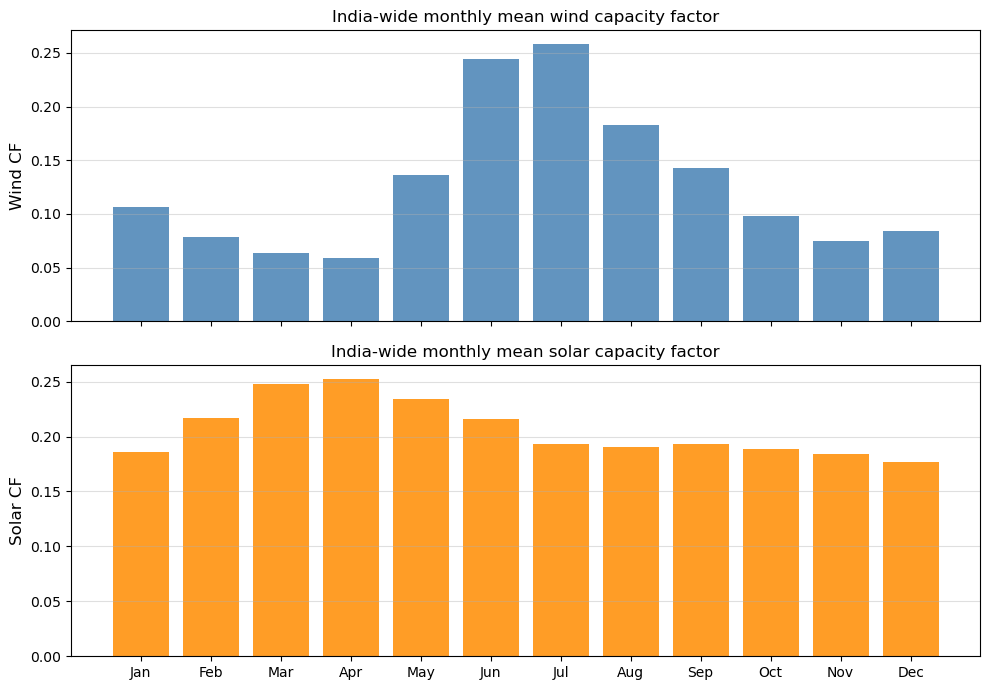

In [20]:
wcf_monthly = wcf.mean(['lat', 'lon']).resample(time='ME').mean().compute()
scf_monthly = scf.mean(['lat', 'lon']).resample(time='ME').mean().compute()

month_labels = pd.date_range('2025-01', periods=12, freq='ME').strftime('%b')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.bar(range(12), wcf_monthly.values, color='steelblue', alpha=0.85)
ax1.set_ylabel('Wind CF', fontsize=12)
ax1.set_title('India-wide monthly mean wind capacity factor', fontsize=12)
ax1.set_ylim(0)
ax1.grid(axis='y', alpha=0.4)

ax2.bar(range(12), scf_monthly.values, color='darkorange', alpha=0.85)
ax2.set_ylabel('Solar CF', fontsize=12)
ax2.set_title('India-wide monthly mean solar capacity factor', fontsize=12)
ax2.set_xticks(range(12))
ax2.set_xticklabels(month_labels)
ax2.set_ylim(0)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_monthly_ts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Diurnal cycle

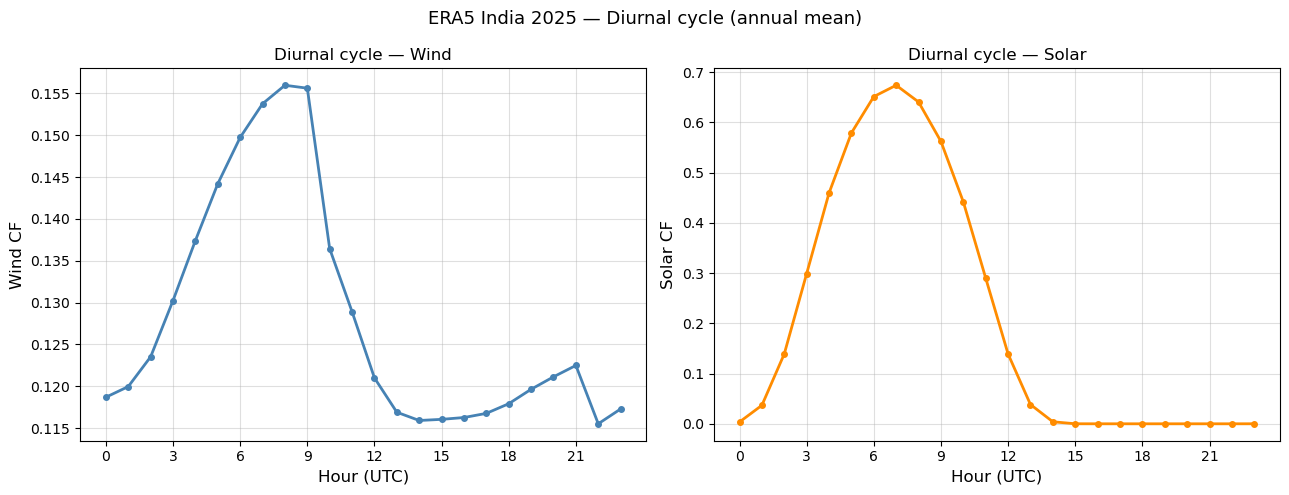

In [21]:
wcf_diurnal = wcf.mean(['lat', 'lon']).groupby('time.hour').mean().compute()
scf_diurnal = scf.mean(['lat', 'lon']).groupby('time.hour').mean().compute()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(wcf_diurnal.hour, wcf_diurnal.values, color='steelblue', lw=2, marker='o', ms=4)
ax1.set_xlabel('Hour (UTC)', fontsize=12)
ax1.set_ylabel('Wind CF', fontsize=12)
ax1.set_title('Diurnal cycle — Wind', fontsize=12)
ax1.set_xticks(range(0, 24, 3))
ax1.grid(alpha=0.4)

ax2.plot(scf_diurnal.hour, scf_diurnal.values, color='darkorange', lw=2, marker='o', ms=4)
ax2.set_xlabel('Hour (UTC)', fontsize=12)
ax2.set_ylabel('Solar CF', fontsize=12)
ax2.set_title('Diurnal cycle — Solar', fontsize=12)
ax2.set_xticks(range(0, 24, 3))
ax2.grid(alpha=0.4)

plt.suptitle('ERA5 India 2025 — Diurnal cycle (annual mean)', fontsize=13)
plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_diurnal_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Distribution of hourly capacity factors

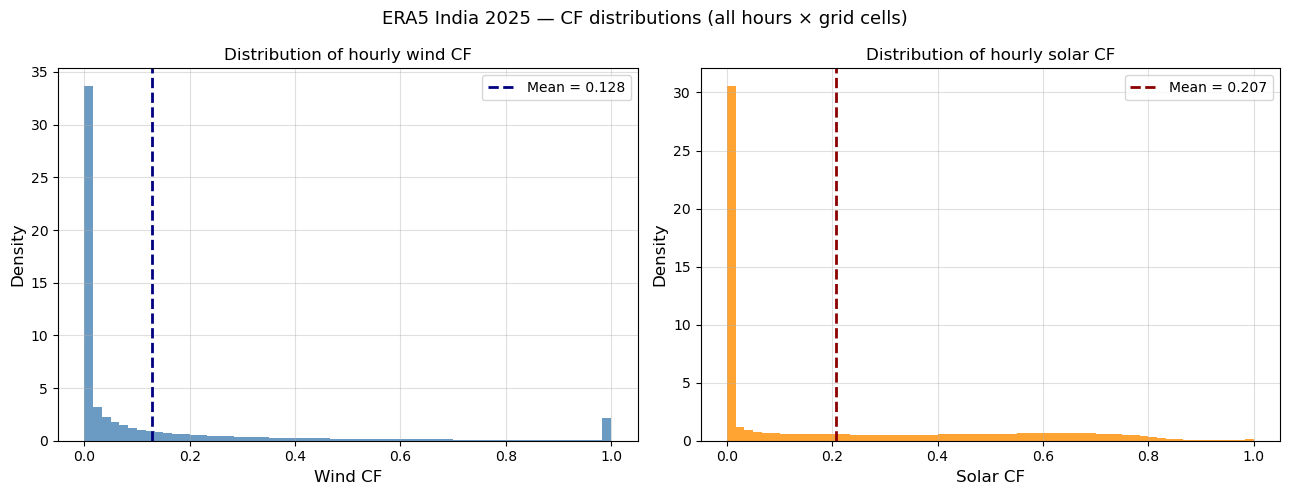

In [22]:
wcf_flat = wcf.values.flatten()
scf_flat = scf.values.flatten()
wcf_flat = wcf_flat[~np.isnan(wcf_flat)]
scf_flat = scf_flat[~np.isnan(scf_flat)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(wcf_flat, bins=60, color='steelblue', alpha=0.8, density=True)
ax1.axvline(wcf_flat.mean(), color='navy', lw=2, ls='--',
            label=f'Mean = {wcf_flat.mean():.3f}')
ax1.set_xlabel('Wind CF', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of hourly wind CF', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.4)

ax2.hist(scf_flat, bins=60, color='darkorange', alpha=0.8, density=True)
ax2.axvline(scf_flat.mean(), color='darkred', lw=2, ls='--',
            label=f'Mean = {scf_flat.mean():.3f}')
ax2.set_xlabel('Solar CF', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of hourly solar CF', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.4)

plt.suptitle('ERA5 India 2025 — CF distributions (all hours × grid cells)', fontsize=13)
plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_cf_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Monsoon vs non-monsoon comparison

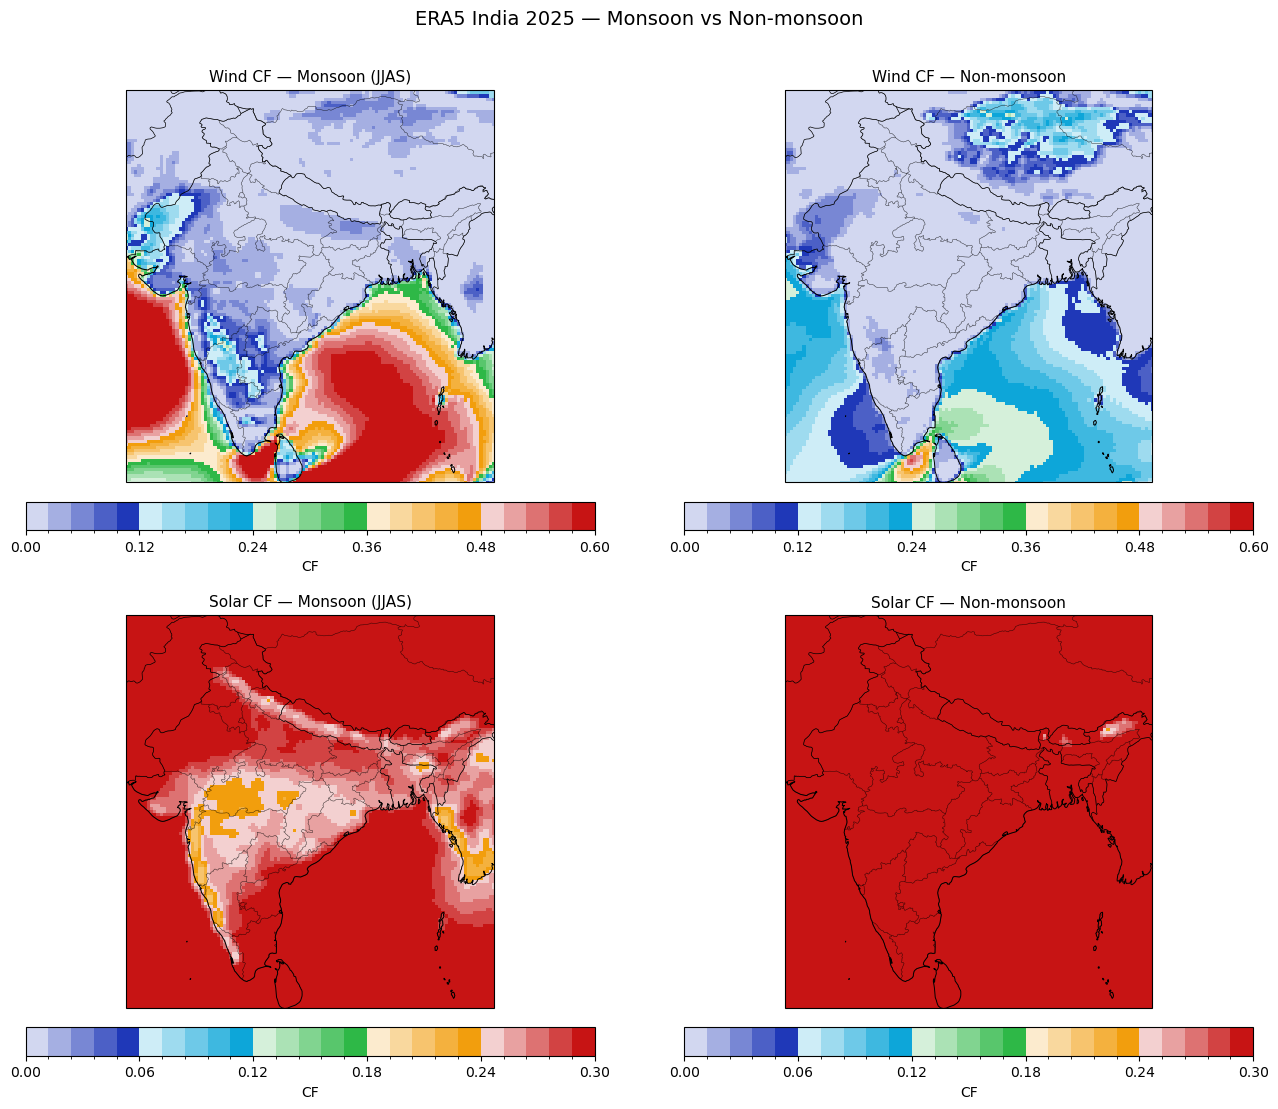

In [23]:
monsoon     = [6, 7, 8, 9]
non_monsoon = [1, 2, 3, 4, 5, 10, 11, 12]

panels = [
    (wcf.sel(time=wcf.time.dt.month.isin(monsoon)).mean('time').compute(),
     'Wind CF — Monsoon (JJAS)',  0, 0.6),
    (wcf.sel(time=wcf.time.dt.month.isin(non_monsoon)).mean('time').compute(),
     'Wind CF — Non-monsoon',     0, 0.6),
    (scf.sel(time=scf.time.dt.month.isin(monsoon)).where(
        scf.sel(time=scf.time.dt.month.isin(monsoon)) > 0).mean('time', skipna=True).compute(),
     'Solar CF — Monsoon (JJAS)', 0, 0.30),
    (scf.sel(time=scf.time.dt.month.isin(non_monsoon)).where(
        scf.sel(time=scf.time.dt.month.isin(non_monsoon)) > 0).mean('time', skipna=True).compute(),
     'Solar CF — Non-monsoon',    0, 0.30),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, (da, title, vmin, vmax) in zip(axes.flat, panels):
    norm = cf_norm(vmin, vmax)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    im = ax.pcolormesh(da.lon, da.lat, da.values,
                       cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.8,
                 label='CF', ticks=np.linspace(vmin, vmax, 6))
    ax.set_title(title, fontsize=11)
    ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())

plt.suptitle('ERA5 India 2025 — Monsoon vs Non-monsoon', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../../data/proc/era5/fig_monsoon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary statistics

In [ ]:
stats = pd.DataFrame({
    'Wind CF': {
        'Mean':   float(wcf.mean()),
        'Median': float(wcf.median()),
        'Std':    float(wcf.std()),
        'P10':    float(wcf.quantile(0.10)),
        'P90':    float(wcf.quantile(0.90)),
        'Max':    float(wcf.max()),
    },
    'Solar CF': {
        'Mean':   float(scf.mean()),
        'Median': float(scf.median()),
        'Std':    float(scf.std()),
        'P10':    float(scf.quantile(0.10)),
        'P90':    float(scf.quantile(0.90)),
        'Max':    float(scf.max()),
    },
})
stats.round(4)

,Wind CF,Solar CF
Mean,0.1280,0.2065
Median,0.0041,0.0106
Std,0.2302,0.2544
P10,0.0000,0.0000
P90,0.4578,0.6660
Max,1.0000,1.0000


: 